In [ ]:
#*****************************************************************
# Date:         February, 2026
# Author:       Opeoluwa Adebayo, ooadebayo@mun.ca
# Institution:  Memorial University of Newfoundland, St. John's, NL
#*****************************************************************

In [69]:
# Import the necessary libraries
import numpy as np
import control as ct
from scipy import signal
import matplotlib.pyplot as plt
import seaborn as sns       # Optional
import warnings

# Suppress runtime warning
warnings.filterwarnings("ignore")

In [70]:
# Set Seaborn style for plots
sns.set_theme()

In [71]:
#****** State Space Model **************

# Define the state space matrices for the system
A = np.array([
    [-0.0085, 0, 0.0085],
    [0, -0.0195, 0.0084],
    [0.0085, 0.0084, -0.0169]
])

B = np.array([
    [0.0065, 0],
    [0, 0.0065],
    [0, 0]
])

C = np.eye(3)       # 3 x 3 identity matrix

D = np.zeros((3, 2))  # 3 x 2 zero matrix

# Create a state space model for the tank system
sys = ct.ss(A, B, C, D, name="three tank sys", states=["h1", "h2", "h3"],
            inputs=["Q1", "Q2"], outputs=["h1", "h2", "h3"])

print(sys)

<StateSpace>: three tank sys
Inputs (2): ['Q1', 'Q2']
Outputs (3): ['h1', 'h2', 'h3']
States (3): ['h1', 'h2', 'h3']

A = [[-0.0085  0.      0.0085]
     [ 0.     -0.0195  0.0084]
     [ 0.0085  0.0084 -0.0169]]

B = [[0.0065 0.    ]
     [0.     0.0065]
     [0.     0.    ]]

C = [[1. 0. 0.]
     [0. 1. 0.]
     [0. 0. 1.]]

D = [[0. 0.]
     [0. 0.]
     [0. 0.]]


In [72]:
#******** Step Response of the Model ***************

# Solve the state space model for a unit step change in Q1 and Q2
step_response = ct.step_response(sys)

# Extract the time, states and outputs
t = step_response.time
x = step_response.states   # dimension: x[num_states, num_inputs, time]
y = step_response.outputs  # dimension: y[num_outputs, num_inputs, time]

# Output reponse based on the unit step change in Q1 and Q2
h_Q1 = y[:, 0, :]   # dimension: h_Q1[num_outputs, time]
h_Q2 = y[:, 1, :]   # dimension: h_Q2[num_outputs, time]

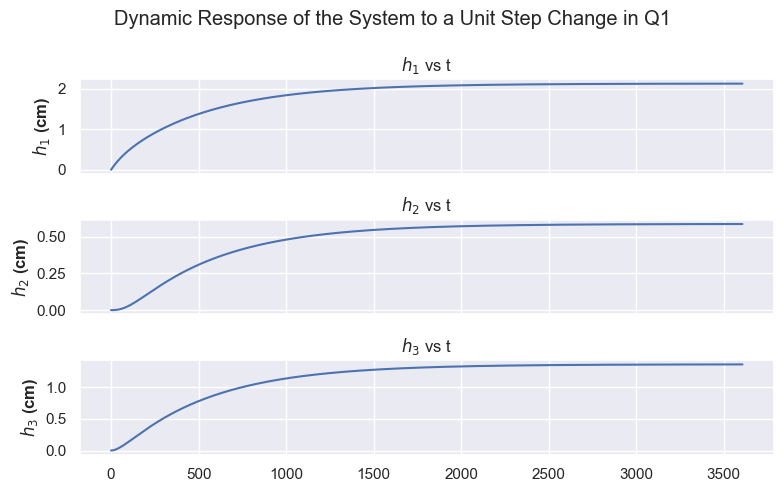

In [73]:
#******** Plot of Step Response in Q1 *************

# Figure having 3 rows and 1 column plots
fig, ax = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
ax = ax.flatten()

# h1 response
ax[0].plot(t, h_Q1[0, :])
ax[0].set_ylabel(r'$h_1$ (cm)', weight='demibold')
ax[0].set_title(r'$h_1$ vs t')

# h2 response
ax[1].plot(t, h_Q1[1, :])
ax[1].set_ylabel(r'$h_2$ (cm)', weight='demibold')
ax[1].set_title(r'$h_2$ vs t')

# h3 response
ax[2].plot(t, h_Q1[2, :])
ax[2].set_ylabel(r'$h_3$ (cm)', weight='demibold')
ax[2].set_title(r'$h_3$ vs t')

fig.suptitle("Dynamic Response of the System to a Unit Step Change in Q1")
fig.tight_layout()

plt.show()

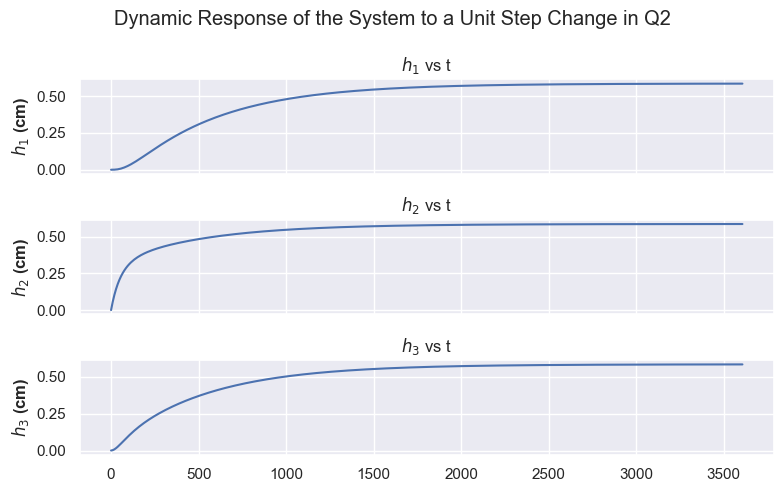

In [74]:
#******** Plot of Step Response in Q2 *************

# Figure having 3 rows and 1 column plots
fig, ax = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
ax = ax.flatten()

# h1 response
ax[0].plot(t, h_Q2[0, :])
ax[0].set_ylabel(r'$h_1$ (cm)', weight='demibold')
ax[0].set_title(r'$h_1$ vs t')

# h2 response
ax[1].plot(t, h_Q2[1, :])
ax[1].set_ylabel(r'$h_2$ (cm)', weight='demibold')
ax[1].set_title(r'$h_2$ vs t')

# h3 response
ax[2].plot(t, h_Q2[2, :])
ax[2].set_ylabel(r'$h_3$ (cm)', weight='demibold')
ax[2].set_title(r'$h_3$ vs t')

fig.suptitle("Dynamic Response of the System to a Unit Step Change in Q2")
fig.tight_layout()

plt.show()

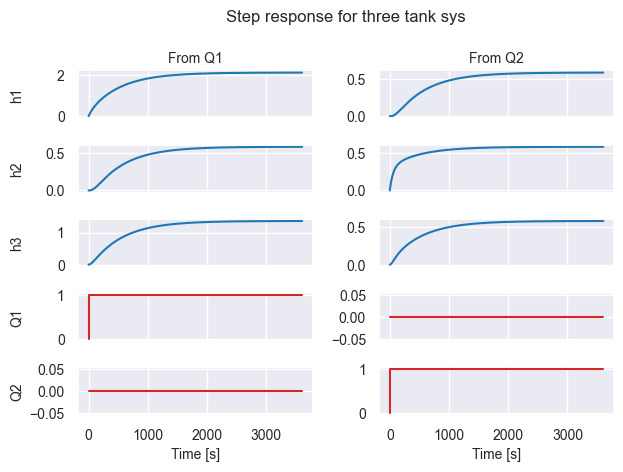

In [75]:
#******* Alternative step response plot *********

# we can plot directly using the object of the step_response we generated
cplt = step_response.plot(plot_inputs=True)

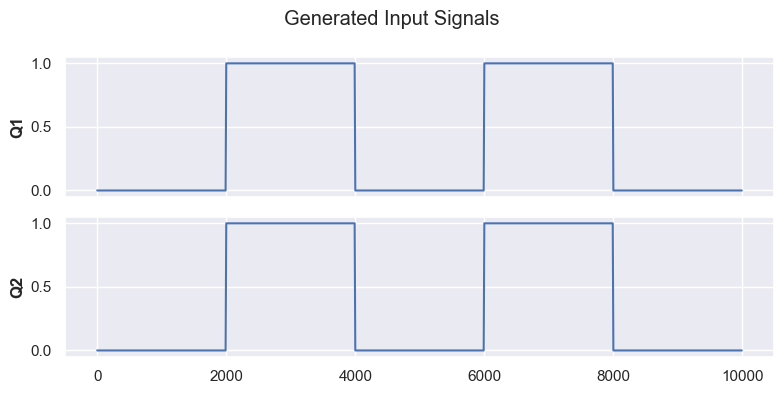

In [76]:
#********* Dynamic Response to Generated Square Input Signals **********

# Signal parameters
period = 4000
t_final = 10000     # total simulation time
Ts = 10             # sampling time

# Time vector
t = np.arange(0, t_final, Ts)

# Frequency
f = 1 / period

# Square wave (±0) for Q1 and Q2 
Q1 = 0.5*(1-signal.square(2 * np.pi * f * t))
Q2 = 0.5*(1-signal.square(2 * np.pi * f * t))

# Plot of the generated signals
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax = ax.flatten()

# plot of Q1
ax[0].plot(t, Q1)
ax[0].set_ylabel("Q1", weight="demibold")

# plot of Q2
ax[1].plot(t, Q2)
ax[1].set_ylabel("Q2", weight="demibold")

fig.suptitle("Generated Input Signals")
fig.tight_layout()

plt.show()

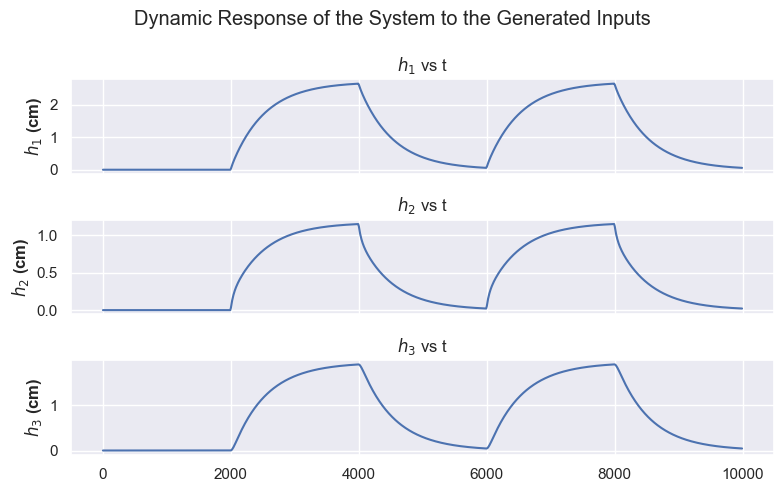

In [77]:
# Define the input by combining Q1 and Q2
num_inputs = 2
U = np.zeros((num_inputs, len(t)))

U[0, :] = Q1
U[1, :] = Q2


# Method 1: We can use forced_response to simulate the dynamic response. It is similar to MATLAB's lsim
response = ct.forced_response(sys, t, U)

# Extract time and output for plotting
time = response.time   # Optional: It is the same as "t"
y_response = response.outputs   # dimension: y_response[num_outputs, time]

# Plot of the dynamic response
fig, ax = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
ax = ax.flatten()

# h1 response
ax[0].plot(t, y_response[0, :])
ax[0].set_ylabel(r'$h_1$ (cm)', weight='demibold')
ax[0].set_title(r'$h_1$ vs t')

# h2 response
ax[1].plot(t, y_response[1, :])
ax[1].set_ylabel(r'$h_2$ (cm)', weight='demibold')
ax[1].set_title(r'$h_2$ vs t')

# h3 response
ax[2].plot(t, y_response[2, :])
ax[2].set_ylabel(r'$h_3$ (cm)', weight='demibold')
ax[2].set_title(r'$h_3$ vs t')

fig.suptitle("Dynamic Response of the System to the Generated Inputs")
fig.tight_layout()

plt.show()

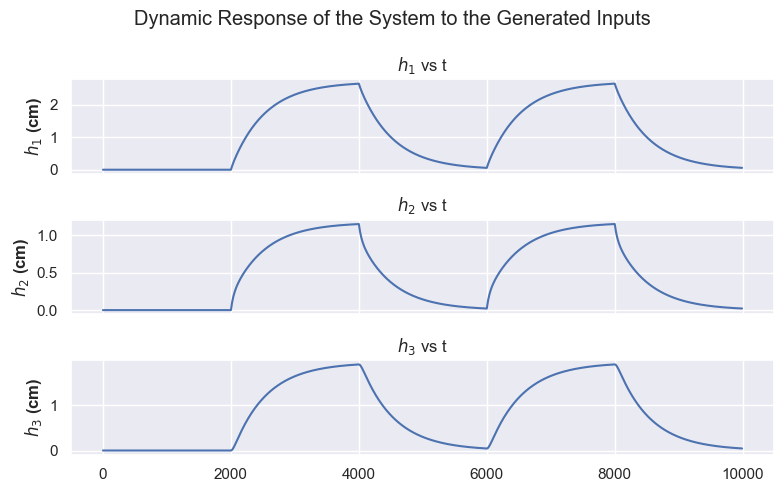

In [ ]:
# Method 2: We can discretize the state space and simulate by iterating the discrete state equations
sysd = ct.sample_system(sys, Ts, method="zoh")  # Discrete state space model

# Extract the necessary discretized matrices
A_d = sysd.A
B_d = sysd.B
C_d = sysd.C
D_d = sysd.D

# Parameters
N = len(t)       # number of samples
num_states = A_d.shape[0]
num_outputs = C_d.shape[0]

# Initialize the state and output vector
x = np.zeros((num_states, N+1))
y = np.zeros((num_states, N))

# Input vector
num_inputs = 2
u = np.zeros((num_inputs, N))

u[0, :] = Q1
u[1, :] = Q2

# Loop through the time step
for k in range(N):
    y[:,k] = C_d @ x[:,k] + D_d @ u[:, k]
    x[:, k+1] = A_d @ x[:, k] + B_d @ u[:, k]


# Plot of the dynamic response
fig, ax = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
ax = ax.flatten()

# h1 response
ax[0].plot(t, y[0, :])
ax[0].set_ylabel(r'$h_1$ (cm)', weight='demibold')
ax[0].set_title(r'$h_1$ vs t')

# h2 response
ax[1].plot(t, y[1, :])
ax[1].set_ylabel(r'$h_2$ (cm)', weight='demibold')
ax[1].set_title(r'$h_2$ vs t')

# h3 response
ax[2].plot(t, y[2, :])
ax[2].set_ylabel(r'$h_3$ (cm)', weight='demibold')
ax[2].set_title(r'$h_3$ vs t')

fig.suptitle("Dynamic Response of the System to the Generated Inputs")
fig.tight_layout()

plt.show()